In [1]:
from IPython.display import HTML
HTML
HTML("""
<video width=1024 controls>
  <source src="1110628_Sport_Fast_1280x720.mp4" type="video/mp4">
</video>"""
)

In [3]:
import cv2
import matplotlib.pyplot as plt
import sys
net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000_fp16.caffemodel")


In [5]:
videoName = "1110628_Sport_Fast_1280x720.mp4"
def face(img):
    imgH, imgW = img.shape[0], img.shape[1]
    print(img.shape)
    mean = [124, 117, 170]
    blob = cv2.dnn.blobFromImage(img, 1.0, (imgW, imgH), mean, swapRB = False,  crop = False)
    # print(blob)
    
    net.setInput(blob)
    detections = net.forward()
    
    confThresh = 0.4
    for i in range(detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        if confidence > confThresh:
            xLeft = int(detections[0, 0, i, 3] * imgW)
            yLeft = int(detections[0, 0, i, 4] * imgH)
            xRight = int(detections[0, 0, i, 5] * imgW - xLeft)
            yRight = int(detections[0, 0, i, 6] * imgH - yLeft)        
            # confStr = "Confidence : " + str(confidence)
            # cv2.putText(img, confStr, (xLeft, yLeft), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255))
    return img, (xLeft, yLeft, xRight, yRight)
def drawRect(frame, bbox):
    p1 = (bbox[0], bbox[1])
    p2 = (bbox[0] + bbox[2], bbox[1] + bbox[3])
    cv2.rectangle(frame, p1, p2, (255, 0, 0), 2, 1)
    
def displayRect(frame, bbox):
    plt.figure(figsize = (20, 10))
    frameCopy = frame.copy()
    drawRect(frameCopy, bbox)
    frameCopy = cv2.cvtColor(frameCopy, cv2.COLOR_BGR2RGB)
    plt.imshow(frameCopy); plt.axis('off')
    
def drawText(frame, txt, location, color = (50, 150, 50)):
    cv2.putText(frame, txt, location, cv2.FONT_HERSHEY_SIMPLEX, 1, color, 3)
    

In [7]:
video = cv2.VideoCapture(videoName)
ok, frame = video.read()

if not video.isOpened():
    print("Couldn't open video")
    sys.exit()
else:
    w = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
videoResName = "result_1110628_Sport_Fast_1280x720.mp4"
videoOut = cv2.VideoWriter(videoResName, cv2.VideoWriter_fourcc(*'avc1'), 10, (w, h))

(720, 1280, 3)


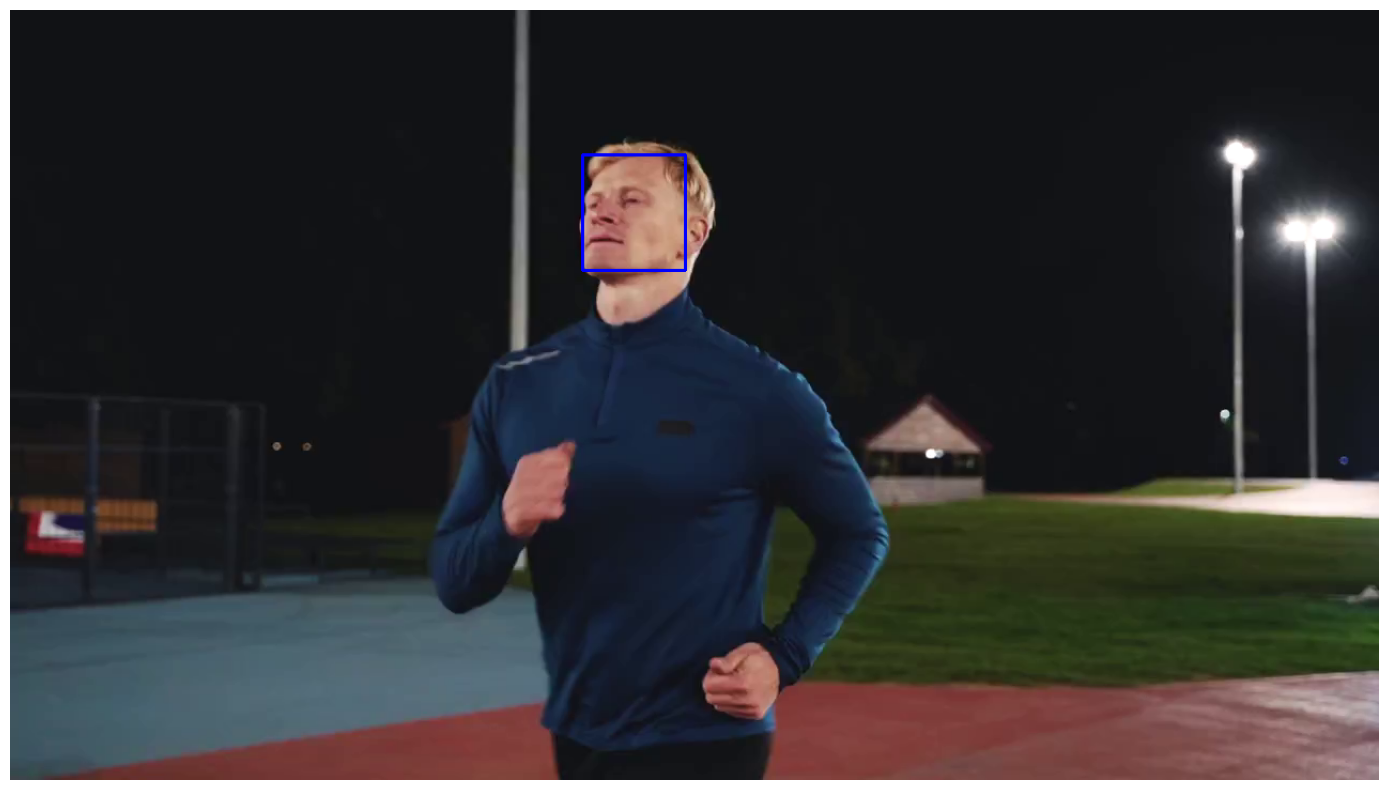

In [9]:
# bbox0 = (520, 120, 140, 140)
_, bbox0 = face(frame)
displayRect(frame, bbox0)

In [11]:
tracker = cv2.TrackerGOTURN_create()
tracker.init(frame, bbox0)

In [ ]:
while True:
    ok, frame = video.read()
    if not ok:        
        break
    timer = cv2.getTickCount()
    
    ok, bbox = tracker.update(frame)
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - timer)
    
    if ok:
        drawRect(frame, bbox)
    else:
        drawText(frame, "Tracker doesn't find anything", (80, 100), (0, 0, 255))
        
    drawText(frame, "FPS : " + str(int(fps)), (80, 150))
    videoOut.write(frame)
video.release()
videoOut.release()